# Walsh Coefficient Visualization

This notebook loads the Walsh coefficients and visualizes their distribution with a histogram, per-order comparisons, and a zero-centered density plot.

## 1. Load Data and Configure Plotting

Import libraries, load the dataset, and set a plotting style.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

csv_path = "../nk_walsh_coefficients.csv"

df = pd.read_csv(csv_path)
df.head()

,order,indices,coefficient
0,0,NaN,0.498435
1,1,602,-0.000611
2,1,499,0.000605
3,1,708,-0.000577
4,1,22,0.000540


## 2. Draw Histogram

Plot a histogram of the coefficient values.

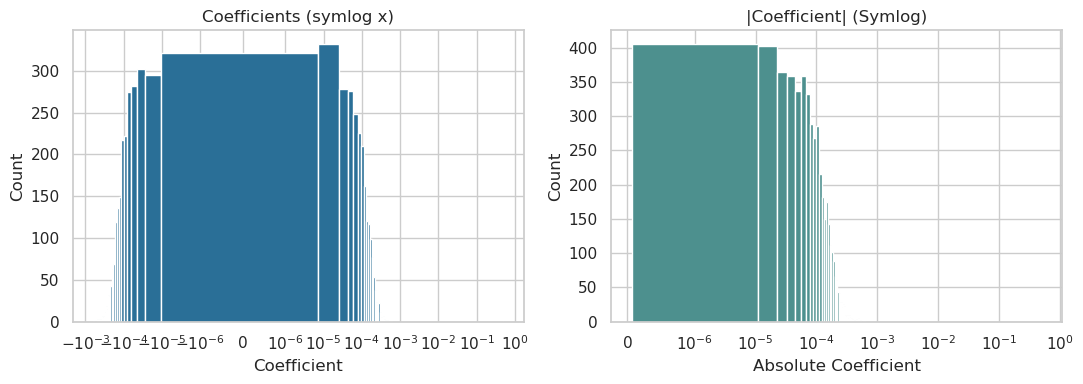

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["coefficient"], bins="fd", color="#2a6f97", edgecolor="white")
axes[0].set_xscale("symlog", linthresh=1e-6)
axes[0].set_title("Coefficients (symlog x)")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Count")

axes[1].hist(np.abs(df["coefficient"]), bins="fd", color="#4d908e", edgecolor="white")
axes[1].set_xscale("symlog", linthresh=1e-6)
axes[1].set_title("|Coefficient| (Symlog)")
axes[1].set_xlabel("Absolute Coefficient")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3. Plot Per-Order Distributions

Compare coefficient distributions across orders.

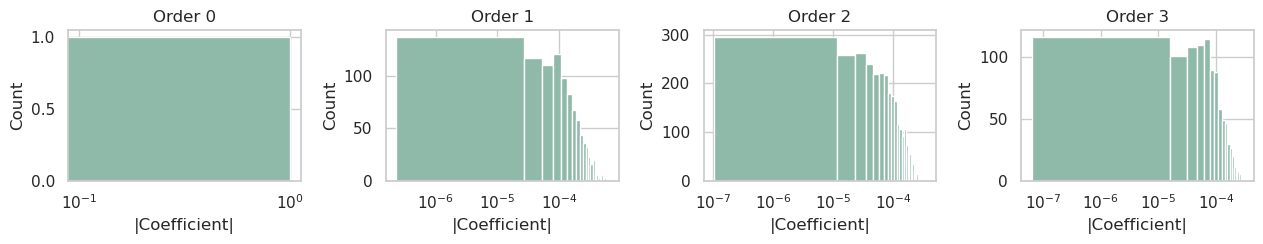

In [13]:
plot_df = df.copy()
plot_df["abs_coefficient"] = plot_df["coefficient"].abs()

orders = sorted(plot_df["order"].unique())
cols = 4
rows = int(np.ceil(len(orders) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 2.6), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, order in zip(axes, orders):
    data = plot_df.loc[plot_df["order"] == order, "abs_coefficient"]
    ax.hist(data, bins="fd", color="#8fb9a8", edgecolor="white")
    ax.set_xscale("log")
    ax.set_title(f"Order {order}")
    ax.set_xlabel("|Coefficient|")
    ax.set_ylabel("Count")

for ax in axes[len(orders):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Per-Order Distributions with Linear Scale

Show coefficient distributions with linear scale for clearer visibility of the actual shape.


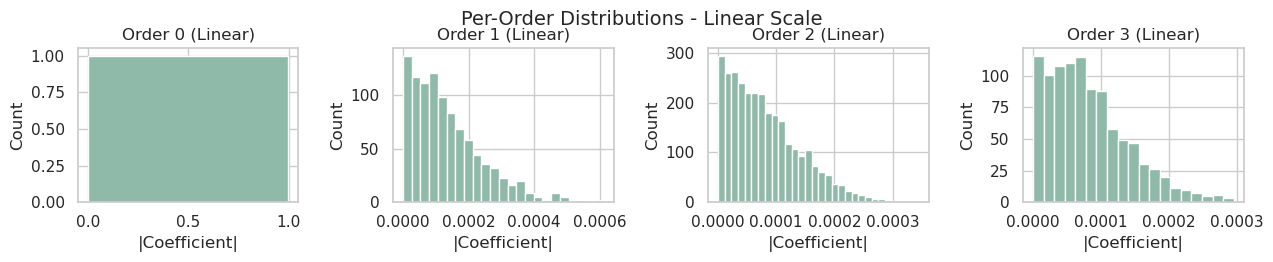

In [5]:
plot_df = df.copy()
plot_df["abs_coefficient"] = plot_df["coefficient"].abs()

orders = sorted(plot_df["order"].unique())
cols = 4
rows = int(np.ceil(len(orders) / cols))

# Linear scale visualization
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 2.6), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, order in zip(axes, orders):
    data = plot_df.loc[plot_df["order"] == order, "abs_coefficient"]
    ax.hist(data, bins="fd", color="#8fb9a8", edgecolor="white")
    ax.set_title(f"Order {order} (Linear)")
    ax.set_xlabel("|Coefficient|")
    ax.set_ylabel("Count")

for ax in axes[len(orders):]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Per-Order Distributions - Linear Scale", y=1.00, fontsize=14)
plt.show()
